### Task 1 - Data Analysis and Preparation

In [ ]:

import pandas as pd
import numpy as np

df = pd.read_csv("AB_NYC_2019.csv")

print("First 5 rows of the dataset:")
print(df.head())


print("\nDataset Shape:")
print(df.shape)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nComplete Summary:")
print(df.describe(include='all'))

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False))

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Values in Each Column:")
print(df.nunique())



print("\nDataset Summary:")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate Rows:", df.duplicated().sum())
print("Total Missing Values:", df.isnull().sum().sum())

First 5 rows of the dataset:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149          

Check the target variable: price

Price Statistics:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Minimum Price: 0
Maximum Price: 10000
Mean Price: 152.7206871868289
Median Price: 106.0


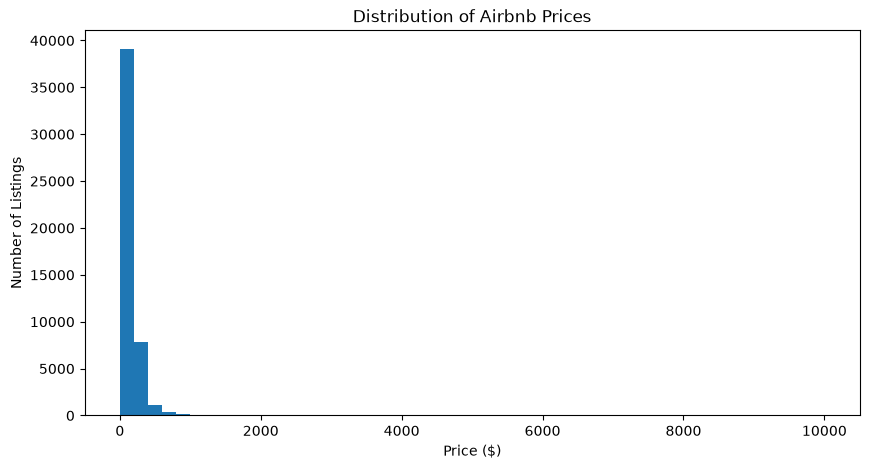

In [109]:
# Basic statistics of price
print("Price Statistics:")
print(df['price'].describe())

# Minimum and maximum price
print("\nMinimum Price:", df['price'].min())
print("Maximum Price:", df['price'].max())
print("Mean Price:", df['price'].mean())
print("Median Price:", df['price'].median())

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50)
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

Check categorical variables


Neighbourhood Group:
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64


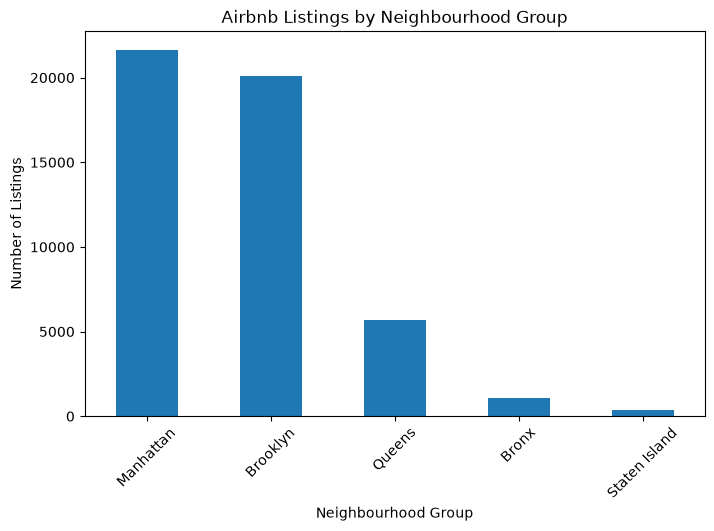

In [110]:
print("Neighbourhood Group:")
print(df['neighbourhood_group'].value_counts())

plt.figure(figsize=(8, 5))
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.title("Airbnb Listings by Neighbourhood Group")
plt.xticks(rotation=45)
plt.show()

Room type

Room Type:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


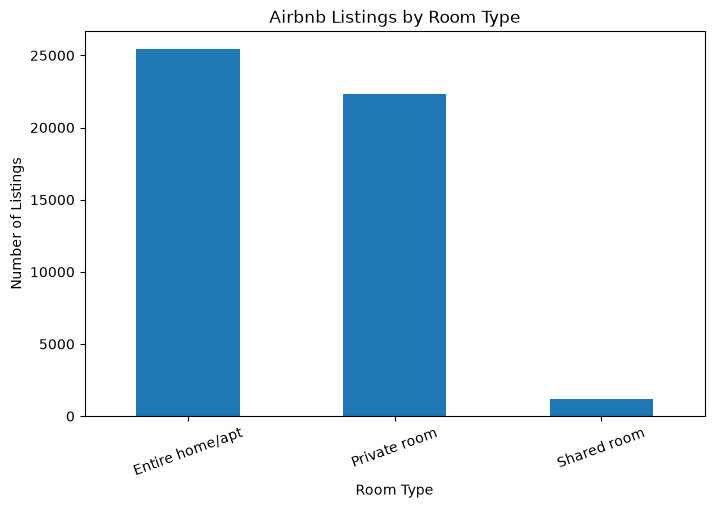

In [111]:
print("Room Type:")
print(df['room_type'].value_counts())

plt.figure(figsize=(8, 5))
df['room_type'].value_counts().plot(kind='bar')
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.title("Airbnb Listings by Room Type")
plt.xticks(rotation=20)
plt.show()

Average price by room type

Average Price by Room Type:
room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64


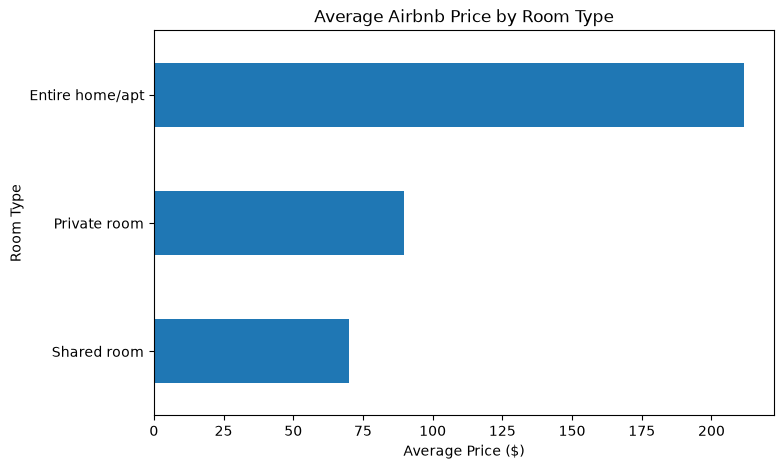

In [112]:
print("Average Price by Room Type:")
print(df.groupby('room_type')['price'].mean().sort_values(ascending=False))

plt.figure(figsize=(8, 5))

df.groupby('room_type')['price'].mean().sort_values().plot(kind='barh')

plt.xlabel("Average Price ($)")
plt.ylabel("Room Type")
plt.title("Average Airbnb Price by Room Type")
plt.show()

Average price by neighbourhood group

Average Price by Neighbourhood Group:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64


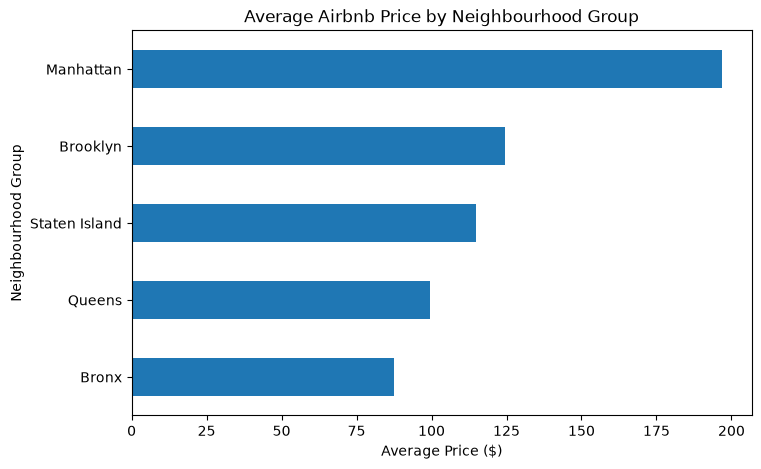

In [113]:
print("Average Price by Neighbourhood Group:")
print(
    df.groupby('neighbourhood_group')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

df.groupby('neighbourhood_group')['price'].mean().sort_values().plot(kind='barh')

plt.xlabel("Average Price ($)")
plt.ylabel("Neighbourhood Group")
plt.title("Average Airbnb Price by Neighbourhood Group")
plt.show()

Price by room type and neighbourhood

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                     127.506596     66.788344    59.800000
Brooklyn                  178.327545     76.500099    50.527845
Manhattan                 249.239109    116.776622    88.977083
Queens                    147.050573     71.762456    69.020202
Staten Island             173.846591     62.292553    57.444444


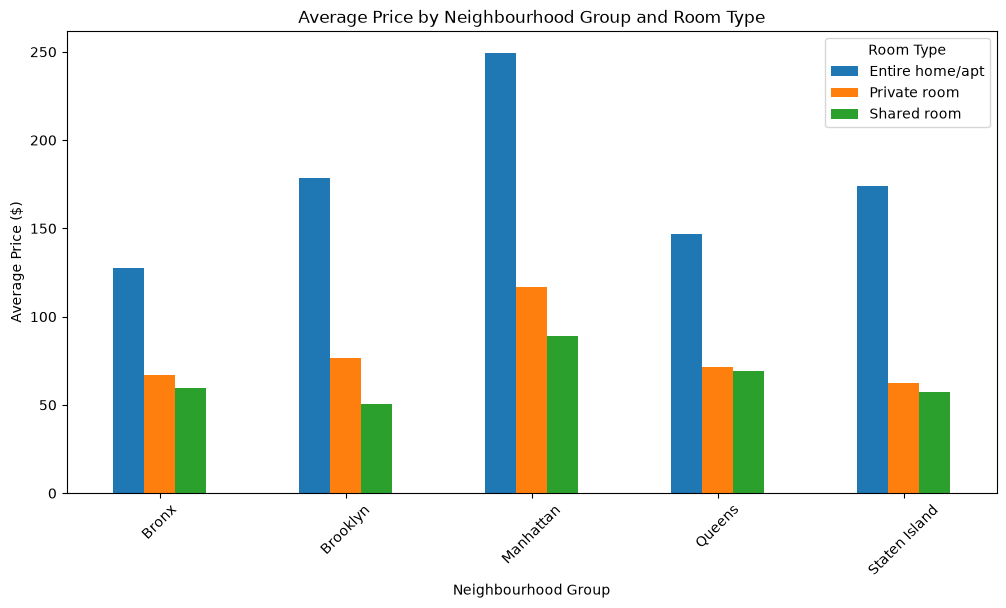

In [114]:
price_table = pd.pivot_table(
    df,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='mean'
)

print(price_table)

price_table.plot(kind='bar', figsize=(12, 6))

plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")
plt.title("Average Price by Neighbourhood Group and Room Type")
plt.xticks(rotation=45)
plt.legend(title="Room Type")
plt.show()

Numerical feature correlations

                                latitude  longitude     price  minimum_nights  \
latitude                        1.000000   0.084788  0.033939        0.024869   
longitude                       0.084788   1.000000 -0.150019       -0.062747   
price                           0.033939  -0.150019  1.000000        0.042799   
minimum_nights                  0.024869  -0.062747  0.042799        1.000000   
number_of_reviews              -0.015389   0.059094 -0.047954       -0.080116   
reviews_per_month              -0.010142   0.145948 -0.030608       -0.121702   
calculated_host_listings_count  0.019517  -0.114713  0.057472        0.127960   
availability_365               -0.010983   0.082731  0.081829        0.144303   

                                number_of_reviews  reviews_per_month  \
latitude                                -0.015389          -0.010142   
longitude                                0.059094           0.145948   
price                                   -0.047954     

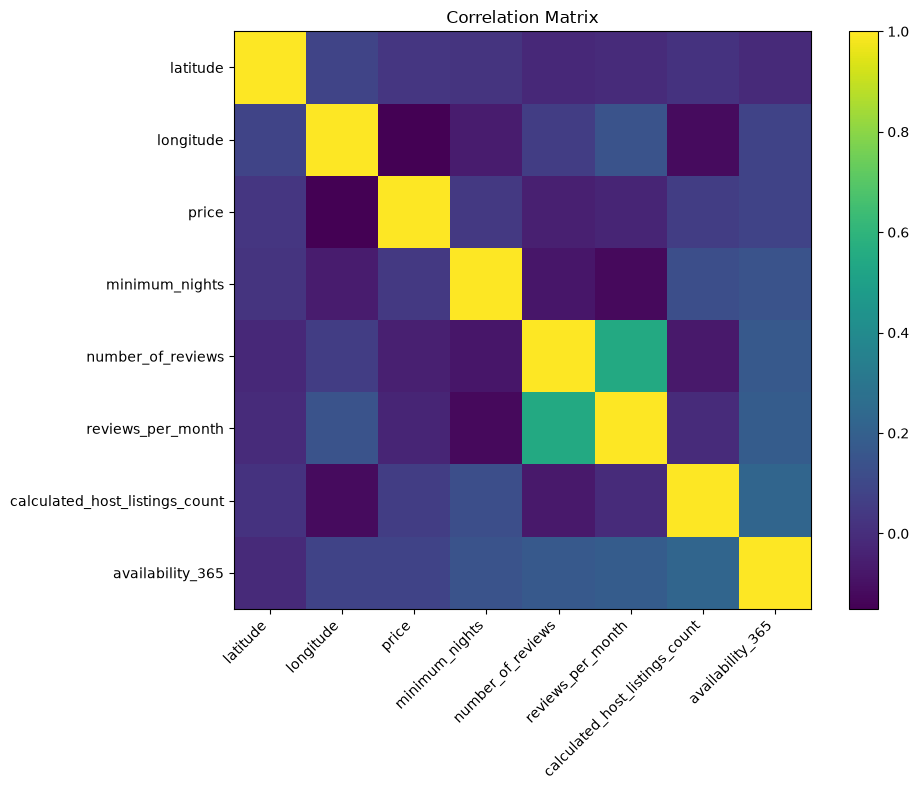

In [115]:
numeric_columns = [
    'latitude',
    'longitude',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

correlation = df[numeric_columns].corr()

print(correlation)

plt.figure(figsize=(10, 8))

plt.imshow(correlation, interpolation='none')
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Check outliers in price

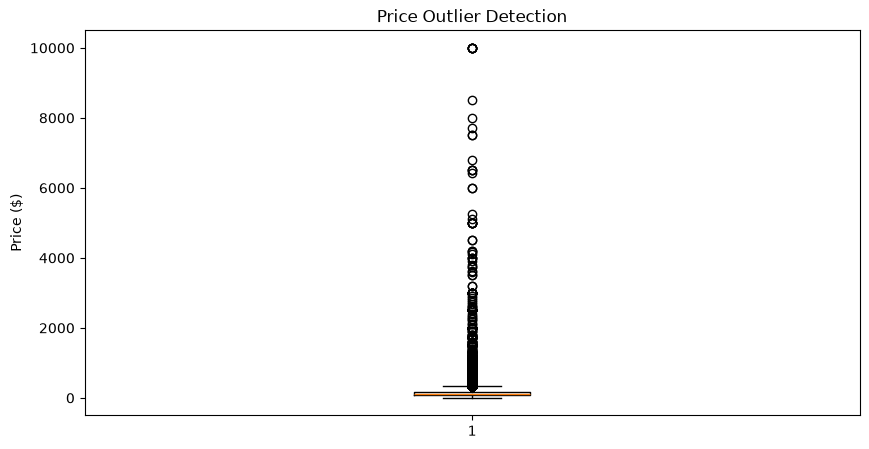

In [116]:
plt.figure(figsize=(10, 5))

plt.boxplot(df['price'])

plt.ylabel("Price ($)")
plt.title("Price Outlier Detection")
plt.show()

In [117]:
print("Highest 20 Prices:")
print(df['price'].sort_values(ascending=False).head(20))

Highest 20 Prices:
29238    10000
9151     10000
17692    10000
6530      9999
40433     9999
12342     9999
30268     8500
4377      8000
29662     7703
42523     7500
45666     7500
44034     6800
48043     6500
3774      6500
37194     6500
29664     6419
15560     6000
3537      6000
3720      5250
43009     5100
Name: price, dtype: int64


Check zero-price listings

In [118]:
print("Listings with price = 0:")
print((df['price'] == 0).sum())

Listings with price = 0:
11


Check minimum nights

In [119]:
print("Minimum Nights Statistics:")
print(df['minimum_nights'].describe())

print("Highest Minimum Nights:")
print(
    df['minimum_nights']
      .sort_values(ascending=False)
      .head(20)
)

Minimum Nights Statistics:
count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64
Highest Minimum Nights:
5767     1250
2854     1000
13404     999
26341     999
38664     999
7355      500
14285     500
11193     500
8014      500
47620     500
10829     480
34487     400
1305      370
15946     366
15980     365
20096     365
17811     365
13788     365
44736     365
31730     365
Name: minimum_nights, dtype: int64


Check reviews

In [120]:
print("Number of Reviews:")
print(df['number_of_reviews'].describe())

print("\nReviews per Month:")
print(df['reviews_per_month'].describe())

Number of Reviews:
count    48895.000000
mean        23.274466
std         44.550582
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

Reviews per Month:
count    38843.000000
mean         1.373221
std          1.680442
min          0.010000
25%          0.190000
50%          0.720000
75%          2.020000
max         58.500000
Name: reviews_per_month, dtype: float64


In [121]:
print(
    "Listings with no reviews:",
    (df['number_of_reviews'] == 0).sum()
)

Listings with no reviews: 10052


Check missing values

In [122]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing = missing[missing['Missing Count'] > 0]

print(missing.sort_values(
    by='Missing Percentage',
    ascending=False
))

                   Missing Count  Missing Percentage
reviews_per_month          10052           20.558339
last_review                10052           20.558339
host_name                     21            0.042949
name                          16            0.032723


Location and room type are among the clearest price-related patterns, while the highly skewed price distribution makes prediction of very expensive listings difficult. The final model therefore uses log-transformed prices while retaining legitimate high-price listings. The dataset does not contain detailed property attributes such as bedrooms, bathrooms, property size, or amenities, which limits the model's ability to explain extreme luxury prices.

### Data Cleaning

In [123]:
# Create a copy for cleaning
data = df.copy()

print("Original shape:", data.shape)

Original shape: (48895, 16)


In [124]:
# Columns that will not be used for prediction
columns_to_drop = [
    'id',
    'name',
    'host_id',
    'host_name'
]

data = data.drop(columns=columns_to_drop)

print("Shape after removing unnecessary columns:", data.shape)
print(data.columns)  

Shape after removing unnecessary columns: (48895, 12)
Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')


In [125]:
print(data.isnull().sum())

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [126]:
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

handle last review date

Check invalid price values

In [127]:
print("Price <= 0:", (data['price'] <= 0).sum())

Price <= 0: 11


In [128]:
data = data[data['price'] > 0]

Handle price outliers

In [129]:
print(data['price'].describe())

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [130]:
print(data['price'].describe())

print("\nTop 30 highest prices:")
print(data[['price', 'room_type', 'neighbourhood_group',
            'neighbourhood']].sort_values(
                by='price',
                ascending=False
            ).head(30))

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Top 30 highest prices:
       price        room_type neighbourhood_group       neighbourhood
9151   10000     Private room              Queens             Astoria
17692  10000  Entire home/apt            Brooklyn          Greenpoint
29238  10000  Entire home/apt           Manhattan     Upper West Side
12342   9999     Private room           Manhattan     Lower East Side
40433   9999  Entire home/apt           Manhattan     Lower East Side
6530    9999  Entire home/apt           Manhattan         East Harlem
30268   8500  Entire home/apt           Manhattan             Tribeca
4377    8000  Entire home/apt            Brooklyn        Clinton Hill
29662   7703  Entire home/apt           Manhattan     Upper East Side
45666   7500     Private room            Brooklyn       East Flatbush
42

In [131]:

# Check how many listings have very high prices

print("Price > $1000:", (data['price'] > 1000).sum())
print("Price > $2000:", (data['price'] > 2000).sum())
print("Price > $5000:", (data['price'] > 5000).sum())
print("Price >= $10000:", (data['price'] >= 10000).sum())

Price > $1000: 239
Price > $2000: 86
Price > $5000: 20
Price >= $10000: 3


In [133]:
print(
    data[data['price'] > 1000][
        ['price', 'minimum_nights', 'room_type',
         'neighbourhood_group', 'neighbourhood']
    ].sort_values('price', ascending=False).head(30)
)

       price  minimum_nights        room_type neighbourhood_group  \
9151   10000             100     Private room              Queens   
17692  10000               5  Entire home/apt            Brooklyn   
29238  10000              30  Entire home/apt           Manhattan   
12342   9999              99     Private room           Manhattan   
6530    9999               5  Entire home/apt           Manhattan   
40433   9999              30  Entire home/apt           Manhattan   
30268   8500              30  Entire home/apt           Manhattan   
4377    8000               1  Entire home/apt            Brooklyn   
29662   7703               1  Entire home/apt           Manhattan   
45666   7500               1     Private room            Brooklyn   
42523   7500               1  Entire home/apt           Manhattan   
44034   6800               1  Entire home/apt           Manhattan   
37194   6500              30     Private room           Manhattan   
3774    6500               1  Enti

In [134]:
# Inspect the 3 highest-price listings

data[data['price'] >= 10000][[
    'price',
    'room_type',
    'neighbourhood_group',
    'neighbourhood',
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365'
]]

,price,room_type,neighbourhood_group,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,availability_365
9151,10000,Private room,Queens,Astoria,40.76810,-73.91651,100,2,0.04,0
17692,10000,Entire home/apt,Brooklyn,Greenpoint,40.73260,-73.95739,5,5,0.16,0
29238,10000,Entire home/apt,Manhattan,Upper West Side,40.77213,-73.98665,30,0,0.00,83


In [135]:
# Inspect the most expensive listings

data[[
    'price',
    'room_type',
    'neighbourhood_group',
    'neighbourhood',
    'minimum_nights',
    'number_of_reviews',
    'availability_365'
]].sort_values(
    by='price',
    ascending=False
).head(25)

,price,room_type,neighbourhood_group,neighbourhood,minimum_nights,number_of_reviews,availability_365
9151,10000,Private room,Queens,Astoria,100,2,0
17692,10000,Entire home/apt,Brooklyn,Greenpoint,5,5,0
29238,10000,Entire home/apt,Manhattan,Upper West Side,30,0,83
12342,9999,Private room,Manhattan,Lower East Side,99,6,83
40433,9999,Entire home/apt,Manhattan,Lower East Side,30,0,365
6530,9999,Entire home/apt,Manhattan,East Harlem,5,1,0
30268,8500,Entire home/apt,Manhattan,Tribeca,30,2,251
4377,8000,Entire home/apt,Brooklyn,Clinton Hill,1,1,365
29662,7703,Entire home/apt,Manhattan,Upper East Side,1,0,146
45666,7500,Private room,Brooklyn,East Flatbush,1,8,179


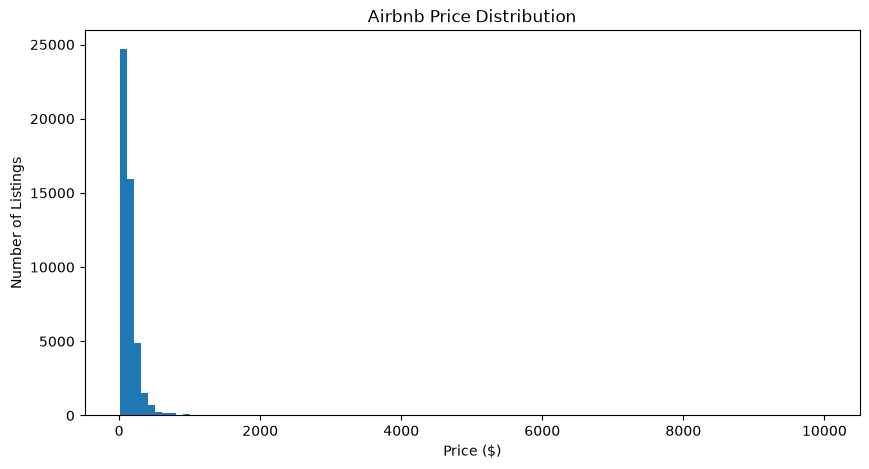

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(data['price'], bins=100)

plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.title("Airbnb Price Distribution")

plt.show()

In [137]:
data.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Feature Engineearing

In [138]:
# Convert date
data['last_review'] = pd.to_datetime(data['last_review'])

# Reference date
reference_date = pd.Timestamp('2019-12-31')

# Feature engineering
data['days_since_last_review'] = (
    reference_date - data['last_review']
).dt.days

# -1 means no review history
data['days_since_last_review'] = (
    data['days_since_last_review'].fillna(-1)
)

# Remove original date
data = data.drop(columns=['last_review'])

# Check
print(data['days_since_last_review'].describe())
print(data[['days_since_last_review']].head(10))

count    48884.000000
mean       359.611959
std        412.042891
min         -1.000000
25%        180.000000
50%        200.000000
75%        422.000000
max       3200.000000
Name: days_since_last_review, dtype: float64
   days_since_last_review
0                   438.0
1                   224.0
2                    -1.0
3                   179.0
4                   407.0
5                   192.0
6                   817.0
7                   190.0
8                   893.0
9                   205.0


In [139]:
# Log transformation of price
data['log_price'] = np.log1p(data['price'])

Feature selaction

In [140]:
features = [
    'neighbourhood_group',
    'neighbourhood',
    'latitude',
    'longitude',
    'room_type',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'days_since_last_review'
]

X = data[features]

In [141]:
# Target variable
y = data['price']

In [142]:
print("Selected Features:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Selected Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']

Number of features: 11
Number of observations: 48884


In [143]:
numeric_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'days_since_last_review',
    'price'
]

correlation = data[numeric_features].corr()

print(correlation['price'].sort_values(ascending=False))

price                             1.000000
availability_365                  0.081847
calculated_host_listings_count    0.057462
minimum_nights                    0.042805
latitude                          0.033899
days_since_last_review           -0.026922
number_of_reviews                -0.047926
reviews_per_month                -0.050531
longitude                        -0.149954
Name: price, dtype: float64


In [144]:
categorical_features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

for col in categorical_features:
    print("\n", col)
    print(data[col].value_counts().head(10))


 neighbourhood_group
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

 neighbourhood
neighbourhood
Williamsburg          3919
Bedford-Stuyvesant    3710
Harlem                2658
Bushwick              2462
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64

 room_type
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64


TRAIN-TEST SPLIT

In [145]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Create price bins
price_bins = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=price_bins
)

preprocessing

In [146]:
categorical_features = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

In [147]:
numerical_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'days_since_last_review'
]

In [148]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Create the pipeline

In [149]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [150]:
linear_pipeline.fit(X_train, y_train)
y_pred = linear_pipeline.predict(X_test)
print("Predictions:", y_pred[:10])

Predictions: [ 90.52936395 225.59631523  54.54821319 176.46619327  83.34678893
 157.83208323 115.24997353 203.51364439 223.125211   203.78299278]


In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 69.67007248346245
RMSE: 203.64337423370904
R²  : 0.13592832244440034


### Random Forest

In [152]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [153]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
print("Random Forest Predictions:", y_pred_rf[:10])

Random Forest Predictions: [ 68.11 257.39  62.51 145.38  79.33 144.99  90.86 156.19 225.4  177.77]


In [154]:

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE :", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²  :", r2_rf)

Random Forest MAE : 64.62265043810304
Random Forest RMSE: 212.29223747166404
Random Forest R²  : 0.06097440489975425


In [155]:
y_log = data['log_price']

In [156]:
X = data[features]

In [157]:
from sklearn.model_selection import train_test_split

price_bins = pd.qcut(
    data['price'],
    q=5,
    labels=False,
    duplicates='drop'
)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42,
    stratify=price_bins
)

### Train Linear Regression on log_price

In [158]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [159]:
linear_log_pipeline.fit(X_train_log, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['neighbourhood_group','neighbourhood','latitude',..., 'calculated_host_listings_count','availability_365', 'days_since_last_review']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [160]:
y_pred_log = linear_log_pipeline.predict(X_test_log)

In [161]:
y_pred_dollars = np.expm1(y_pred_log)
print("Predictions in Dollars:", y_pred_dollars[:10])

Predictions in Dollars: [ 69.98416086 194.58003354  59.25560695 155.37076369  77.87170562
 117.68719559  98.2997198  180.92150641 187.7159702  179.22929135]


In [162]:
# Get the original prices corresponding to X_test_log
y_test_dollars = np.expm1(y_test_log)

mae_log = mean_absolute_error(
    y_test_dollars,
    y_pred_dollars
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test_dollars,
        y_pred_dollars
    )
)

r2_log = r2_score(
    y_test_dollars,
    y_pred_dollars
)

print("Log Linear Regression MAE :", mae_log)
print("Log Linear Regression RMSE:", rmse_log)
print("Log Linear Regression R²  :", r2_log)

Log Linear Regression MAE : 58.44733960425725
Log Linear Regression RMSE: 204.66665664010307
Log Linear Regression R²  : 0.12722280163767863


### Gradient Boosting

In [163]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [164]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['neighbourhood_group','neighbourhood','latitude',..., 'calculated_host_listings_count','availability_365', 'days_since_last_review']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [165]:
y_pred_gb = gb_pipeline.predict(X_test)

In [166]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE :", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²  :", r2_gb)

Gradient Boosting MAE : 64.82287650600652
Gradient Boosting RMSE: 199.08161041621614
Gradient Boosting R²  : 0.17420643993781448


### Hyperparameter Tuning for Gradient Boosting


### RandomizedSearchCV

In [167]:
from sklearn.model_selection import RandomizedSearchCV

In [168]:
param_distributions = {
    'model__n_estimators': [100, 150, 200, 250, 300],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

In [169]:
random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [170]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimat

In [171]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05}

Best CV MAE:
67.214574749844


In [172]:
best_gb = random_search.best_estimator_

In [173]:
y_pred_best = best_gb.predict(X_test)

In [174]:
mae_best = mean_absolute_error(y_test, y_pred_best)

rmse_best = np.sqrt(
    mean_squared_error(y_test, y_pred_best)
)

r2_best = r2_score(y_test, y_pred_best)

print("Tuned Gradient Boosting MAE :", mae_best)
print("Tuned Gradient Boosting RMSE:", rmse_best)
print("Tuned Gradient Boosting R²  :", r2_best)

Tuned Gradient Boosting MAE : 63.533583543970856
Tuned Gradient Boosting RMSE: 201.73143345377113
Tuned Gradient Boosting R²  : 0.15207712755600866


### Gradient Boosting + log_price.

In [175]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

gb_log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])
gb_log_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [176]:
gb_log_pipeline.fit(
    X_train_log,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['neighbourhood_group','neighbourhood','latitude',..., 'calculated_host_listings_count','availability_365', 'days_since_last_review']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [177]:
y_pred_gb_log = gb_log_pipeline.predict(X_test_log)

In [178]:
y_pred_gb_log_dollars = np.expm1(y_pred_gb_log)

In [179]:
y_test_log_dollars = np.expm1(y_test_log)

mae_gb_log = mean_absolute_error(
    y_test_log_dollars,
    y_pred_gb_log_dollars
)

rmse_gb_log = np.sqrt(
    mean_squared_error(
        y_test_log_dollars,
        y_pred_gb_log_dollars
    )
)

r2_gb_log = r2_score(
    y_test_log_dollars,
    y_pred_gb_log_dollars
)

print("Log Gradient Boosting MAE :", mae_gb_log)
print("Log Gradient Boosting RMSE:", rmse_gb_log)
print("Log Gradient Boosting R²  :", r2_gb_log)

Log Gradient Boosting MAE : 55.850101008668894
Log Gradient Boosting RMSE: 201.75861127487047
Log Gradient Boosting R²  : 0.15184864309960444


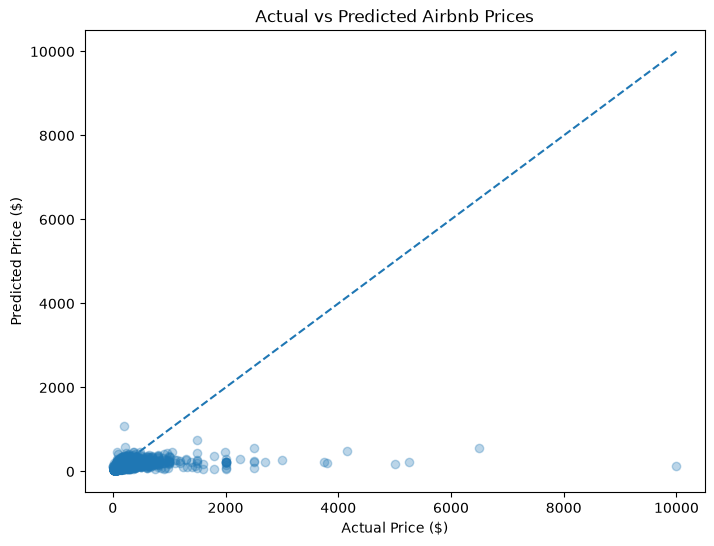

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_log_dollars,
    y_pred_gb_log_dollars,
    alpha=0.3
)

# Perfect prediction line
max_price = max(
    y_test_log_dollars.max(),
    y_pred_gb_log_dollars.max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle='--'
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.show()

Check error by price range

In [181]:
results = pd.DataFrame({
    'actual_price': y_test_log_dollars.values,
    'predicted_price': y_pred_gb_log_dollars
})

results['error'] = (
    results['actual_price'] -
    results['predicted_price']
)

results['absolute_error'] = abs(results['error'])

In [182]:
results['price_range'] = pd.cut(
    results['actual_price'],
    bins=[0, 100, 200, 500, 1000, 5000, np.inf],
    labels=[
        '0-100',
        '101-200',
        '201-500',
        '501-1000',
        '1001-5000',
        '5000+'
    ]
)

In [183]:
mae_by_range = results.groupby(
    'price_range',
    observed=True
)['absolute_error'].mean()

print(mae_by_range)

price_range
0-100          21.516904
101-200        36.246329
201-500       100.109942
501-1000      479.375579
1001-5000    1633.776325
5000+        6408.909196
Name: absolute_error, dtype: float64


In [184]:
results[
    results['actual_price'] >= 1000
].sort_values(
    'actual_price',
    ascending=False
).head(20)

,actual_price,predicted_price,error,absolute_error,price_range
6100,10000.0,141.145682,9858.854318,9858.854318,5000+
2438,6500.0,565.749903,5934.250097,5934.250097,5000+
2745,5250.0,236.000724,5013.999276,5013.999276,5000+
1014,5000.0,171.466908,4828.533092,4828.533092,5000+
7645,4160.0,481.709330,3678.290670,3678.290670,1001-5000
7013,3800.0,199.847707,3600.152293,3600.152293,1001-5000
2829,3750.0,220.361726,3529.638274,3529.638274,1001-5000
7231,3000.0,270.287247,2729.712753,2729.712753,1001-5000
2191,2695.0,228.845514,2466.154486,2466.154486,1001-5000
2806,2500.0,232.670266,2267.329734,2267.329734,1001-5000


In [185]:
print(mae_by_range)

price_range
0-100          21.516904
101-200        36.246329
201-500       100.109942
501-1000      479.375579
1001-5000    1633.776325
5000+        6408.909196
Name: absolute_error, dtype: float64


again feature-engineering 

Create training weights

In [186]:
import numpy as np

# Convert log target back to original price
train_prices = np.expm1(y_train_log)

# Price-aware sample weights
sample_weights = np.log1p(train_prices)

print("Minimum weight:", sample_weights.min())
print("Maximum weight:", sample_weights.max())

Minimum weight: 2.3978952727983707
Maximum weight: 9.210440366976517


In [187]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

weighted_gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

In [188]:
from sklearn.metrics import mean_absolute_error

def dollar_mae_scorer(estimator, X, y):
    # Prediction is in log-price
    pred_log = estimator.predict(X)

    # Convert both actual and predicted values to dollars
    actual_price = np.expm1(y)
    predicted_price = np.expm1(pred_log)

    # Return negative MAE because higher score is better in sklearn
    return -mean_absolute_error(
        actual_price,
        predicted_price
    )

In [189]:
param_distributions_weighted = {
    'model__n_estimators': [100, 150, 200, 250, 300],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__subsample': [0.7, 0.8, 0.9, 1.0]
}

In [190]:
from sklearn.model_selection import RandomizedSearchCV

weighted_random_search = RandomizedSearchCV(
    estimator=weighted_gb_pipeline,
    param_distributions=param_distributions_weighted,
    n_iter=30,
    cv=3,
    scoring=dollar_mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [191]:
weighted_random_search.fit(
    X_train_log,
    y_train_log,
    model__sample_weight=sample_weights
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",<function dol...001E94CAE9EE0>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best es

In [192]:
print("Best Parameters:")
print(weighted_random_search.best_params_)

print("\nBest CV MAE:")
print(-weighted_random_search.best_score_)

Best Parameters:
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__learning_rate': 0.15}

Best CV MAE:
58.633790990170574


In [193]:

best_weighted_gb = weighted_random_search.best_estimator_

y_pred_weighted_log = best_weighted_gb.predict(X_test_log)

y_pred_weighted = np.expm1(y_pred_weighted_log)
y_test_weighted = np.expm1(y_test_log)

In [194]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_weighted = mean_absolute_error(
    y_test_weighted,
    y_pred_weighted
)

rmse_weighted = np.sqrt(
    mean_squared_error(
        y_test_weighted,
        y_pred_weighted
    )
)

r2_weighted = r2_score(
    y_test_weighted,
    y_pred_weighted
)

print("Weighted Log Gradient Boosting MAE :", mae_weighted)
print("Weighted Log Gradient Boosting RMSE:", rmse_weighted)
print("Weighted Log Gradient Boosting R²  :", r2_weighted)

Weighted Log Gradient Boosting MAE : 55.59400860032372
Weighted Log Gradient Boosting RMSE: 196.7308209376178
Weighted Log Gradient Boosting R²  : 0.1935935184759877


In [195]:
weighted_results = pd.DataFrame({
    'actual_price': y_test_weighted.values,
    'predicted_price': y_pred_weighted
})

weighted_results['absolute_error'] = abs(
    weighted_results['actual_price'] -
    weighted_results['predicted_price']
)

weighted_results['price_range'] = pd.cut(
    weighted_results['actual_price'],
    bins=[0, 100, 200, 500, 1000, 5000, np.inf],
    labels=[
        '0-100',
        '101-200',
        '201-500',
        '501-1000',
        '1001-5000',
        '5000+'
    ]
)

In [196]:
weighted_mae_by_range = weighted_results.groupby(
    'price_range',
    observed=True
)['absolute_error'].mean()

print(weighted_mae_by_range)

price_range
0-100          22.854200
101-200        39.831409
201-500        94.439337
501-1000      423.845629
1001-5000    1514.459991
5000+        6448.320813
Name: absolute_error, dtype: float64


In [202]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)



XGBoost version: 3.3.0


### XGboost

In [203]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

In [204]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [205]:
xgb_pipeline.fit(
    X_train_log,
    y_train_log
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['neighbourhood_group','neighbourhood','latitude',..., 'calculated_host_listings_count','availability_365', 'days_since_last_review']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [206]:
y_pred_xgb_log = xgb_pipeline.predict(X_test_log)

In [207]:
y_pred_xgb = np.expm1(y_pred_xgb_log)
y_test_xgb = np.expm1(y_test_log)

In [208]:
mae_xgb = mean_absolute_error(
    y_test_xgb,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test_xgb,
    y_pred_xgb
)

print("XGBoost MAE :", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²  :", r2_xgb)

XGBoost MAE : 54.23810140128466
XGBoost RMSE: 199.12330767350986
XGBoost R²  : 0.1738604819915217


### tune XGBoost

In [209]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_distributions = {
    'model__n_estimators': [200, 300, 400, 500, 600],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'model__max_depth': [3, 4, 5, 6, 7, 8],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 2, 5, 10]
}

In [210]:
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=30,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [211]:
xgb_random_search.fit(
    X_train_log,
    y_train_log
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, 

In [212]:
print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV MAE:")
print(-xgb_random_search.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 2, 'model__reg_alpha': 0.01, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.9}

Best CV MAE:
0.30838322223134407


### tuned XGBoost on the untouched test set

In [213]:
best_xgb = xgb_random_search.best_estimator_

In [214]:
y_pred_tuned_log = best_xgb.predict(X_test_log)

In [215]:
y_pred_tuned = np.expm1(y_pred_tuned_log)
y_test_tuned = np.expm1(y_test_log)

In [216]:
mae_tuned_xgb = mean_absolute_error(
    y_test_tuned,
    y_pred_tuned
)

rmse_tuned_xgb = np.sqrt(
    mean_squared_error(
        y_test_tuned,
        y_pred_tuned
    )
)

r2_tuned_xgb = r2_score(
    y_test_tuned,
    y_pred_tuned
)

print("Tuned XGBoost MAE :", mae_tuned_xgb)
print("Tuned XGBoost RMSE:", rmse_tuned_xgb)
print("Tuned XGBoost R²  :", r2_tuned_xgb)

Tuned XGBoost MAE : 53.679601992372724
Tuned XGBoost RMSE: 197.6922536295132
Tuned XGBoost R²  : 0.18569236676238743


Check price-range performance for Tuned XGBoost

In [217]:
tuned_results = pd.DataFrame({
    'actual_price': y_test_tuned.values,
    'predicted_price': y_pred_tuned
})

tuned_results['absolute_error'] = abs(
    tuned_results['actual_price'] -
    tuned_results['predicted_price']
)

tuned_results['price_range'] = pd.cut(
    tuned_results['actual_price'],
    bins=[0, 100, 200, 500, 1000, 5000, np.inf],
    labels=[
        '0-100',
        '101-200',
        '201-500',
        '501-1000',
        '1001-5000',
        '5000+'
    ]
)

In [218]:
tuned_mae_by_range = tuned_results.groupby(
    'price_range',
    observed=True
)['absolute_error'].mean()

print(tuned_mae_by_range)

price_range
0-100          20.537963
101-200        36.495859
201-500        95.139636
501-1000      431.301931
1001-5000    1549.577672
5000+        6479.569550
Name: absolute_error, dtype: float64


### Get the best tuned pipeline

In [219]:
print(best_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365',
                                                   'days_since_last_review']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighbourhood_group',


In [220]:
import joblib

In [221]:
joblib.dump(
    best_xgb,
    "airbnb_price_model.pkl"
)

['airbnb_price_model.pkl']

In [222]:
model_info = {
    "features": features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "target": "log_price",
    "reference": "2019-12-31",
    "model": "Tuned XGBoost"
}

In [223]:
joblib.dump(
    model_info,
    "airbnb_model_info.pkl"
)

['airbnb_model_info.pkl']

In [224]:
import os

print("Model exists:", os.path.exists("airbnb_price_model.pkl"))
print("Model info exists:", os.path.exists("airbnb_model_info.pkl"))

Model exists: True
Model info exists: True


In [225]:
loaded_model = joblib.load(
    "airbnb_price_model.pkl"
)

In [226]:
test_prediction_log = loaded_model.predict(
    X_test_log.iloc[:5]
)

test_prediction_price = np.expm1(
    test_prediction_log
)

print(test_prediction_price)

[ 65.51223  240.42892   53.82222  160.95236   74.676056]


In [227]:
original_prediction = best_xgb.predict(
    X_test_log.iloc[:5]
)

loaded_prediction = loaded_model.predict(
    X_test_log.iloc[:5]
)

print(
    "Predictions identical:",
    np.allclose(
        original_prediction,
        loaded_prediction
    )
)

Predictions identical: True


Save the final model

In [228]:
import joblib

best_xgb = xgb_random_search.best_estimator_

joblib.dump(
    best_xgb,
    "airbnb_price_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [229]:
model_info = {
    "features": features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "target": "log_price",
    "reference_date": "2019-12-31",
    "model": "Tuned XGBoost"
}

joblib.dump(
    model_info,
    "airbnb_model_info.pkl"
)

print("Model information saved successfully!")

Model information saved successfully!


In [230]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current folder:
d:\ML\202618023_Drashti_DS605\202618023_Lab_04

Files:
['202618023_Lab_04.ipynb', 'AB_NYC_2019.csv', 'airbnb_model_info.pkl', 'airbnb_price_model.pkl']


In [231]:
loaded_model = joblib.load(
    "airbnb_price_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [232]:
test_prediction_log = loaded_model.predict(
    X_test_log.iloc[:5]
)

test_prediction_price = np.expm1(
    test_prediction_log
)

print("Predicted prices:")
print(test_prediction_price)

Predicted prices:
[ 65.51223  240.42892   53.82222  160.95236   74.676056]


In [233]:
original_prediction = best_xgb.predict(
    X_test_log.iloc[:5]
)

loaded_prediction = loaded_model.predict(
    X_test_log.iloc[:5]
)

print(
    "Predictions identical:",
    np.allclose(
        original_prediction,
        loaded_prediction
    )
)

Predictions identical: True
